In [1]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load diamonds dataset
df=sns.load_dataset('diamonds')
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [4]:
# Median carat and mean price
median_carat = df['carat'].median()
mean_price = df['price'].mean()

# Apply filters
premium_df = df[
    (df['cut'].isin(['Ideal', 'Premium'])) &
    (df['color'].isin(['D', 'E', 'F'])) &
    (df['clarity'].isin(['VS1', 'VS2', 'IF'])) &
    (df['carat'] > median_carat) &
    (df['price'] > mean_price)
].copy()
print(premium_df)

       carat      cut color clarity  depth  table  price     x     y     z
5907    0.81    Ideal     F     VS1   61.5   55.0   3933  6.01  5.96  3.68
5917    0.73    Ideal     D     VS1   60.9   55.0   3937  5.83  5.86  3.56
5946    0.72    Ideal     E     VS1   61.1   57.0   3947  5.78  5.81  3.54
5975    0.72  Premium     E      IF   61.3   60.0   3951  5.74  5.71  3.51
5986    0.80    Ideal     F     VS1   61.6   54.0   3953  5.95  5.99  3.68
...      ...      ...   ...     ...    ...    ...    ...   ...   ...   ...
27651   1.70  Premium     F     VS1   60.6   58.0  18598  7.71  7.68  4.66
27677   1.28    Ideal     E      IF   60.7   57.0  18700  7.09  6.99  4.27
27688   1.51    Ideal     E     VS1   61.5   57.0  18729  7.34  7.40  4.53
27735   1.60    Ideal     F     VS1   62.0   56.0  18780  7.47  7.52  4.65
27740   1.71  Premium     F     VS2   62.3   59.0  18791  7.57  7.53  4.70

[1390 rows x 10 columns]


In [5]:
# price per carat
premium_df['price_per_carat'] = premium_df['price'] / premium_df['carat']
print("price_per_carat")
print(premium_df['price_per_carat'])
# volume = x * y * z
premium_df['volume'] = premium_df['x'] * premium_df['y'] * premium_df['z']
print("volume")
print(premium_df['volume'])

# Min-Max normalization for value_score
premium_df['value_score'] = (
    (premium_df['price_per_carat'] - premium_df['price_per_carat'].min()) /
    (premium_df['price_per_carat'].max() - premium_df['price_per_carat'].min())
)
print("value_score")
print(premium_df['value_score'])

# log_price
premium_df['log_price'] = np.log(premium_df['price'])
print("log_price")
print(premium_df['log_price'])




price_per_carat
5907      4855.555556
5917      5393.150685
5946      5481.944444
5975      5487.500000
5986      4941.250000
             ...     
27651    10940.000000
27677    14609.375000
27688    12403.311258
27735    11737.500000
27740    10988.888889
Name: price_per_carat, Length: 1390, dtype: float64
volume
5907     131.816128
5917     121.623128
5946     118.879572
5975     115.041654
5986     131.157040
            ...    
27651    275.931648
27677    211.617357
27688    246.051480
27735    261.210960
27740    267.909870
Name: volume, Length: 1390, dtype: float64
value_score
5907     0.029782
5917     0.072438
5946     0.079483
5975     0.079924
5986     0.036581
           ...   
27651    0.512561
27677    0.803713
27688    0.628669
27735    0.575839
27740    0.516440
Name: value_score, Length: 1390, dtype: float64
log_price
5907     8.277158
5917     8.278174
5946     8.280711
5975     8.281724
5986     8.282230
           ...   
27651    9.830809
27677    9.836279
27688   

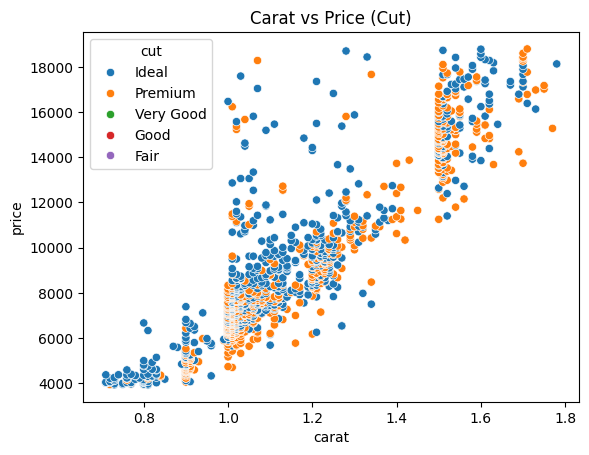

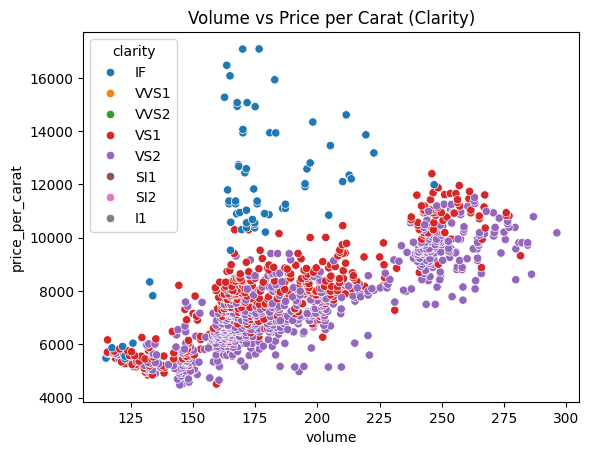

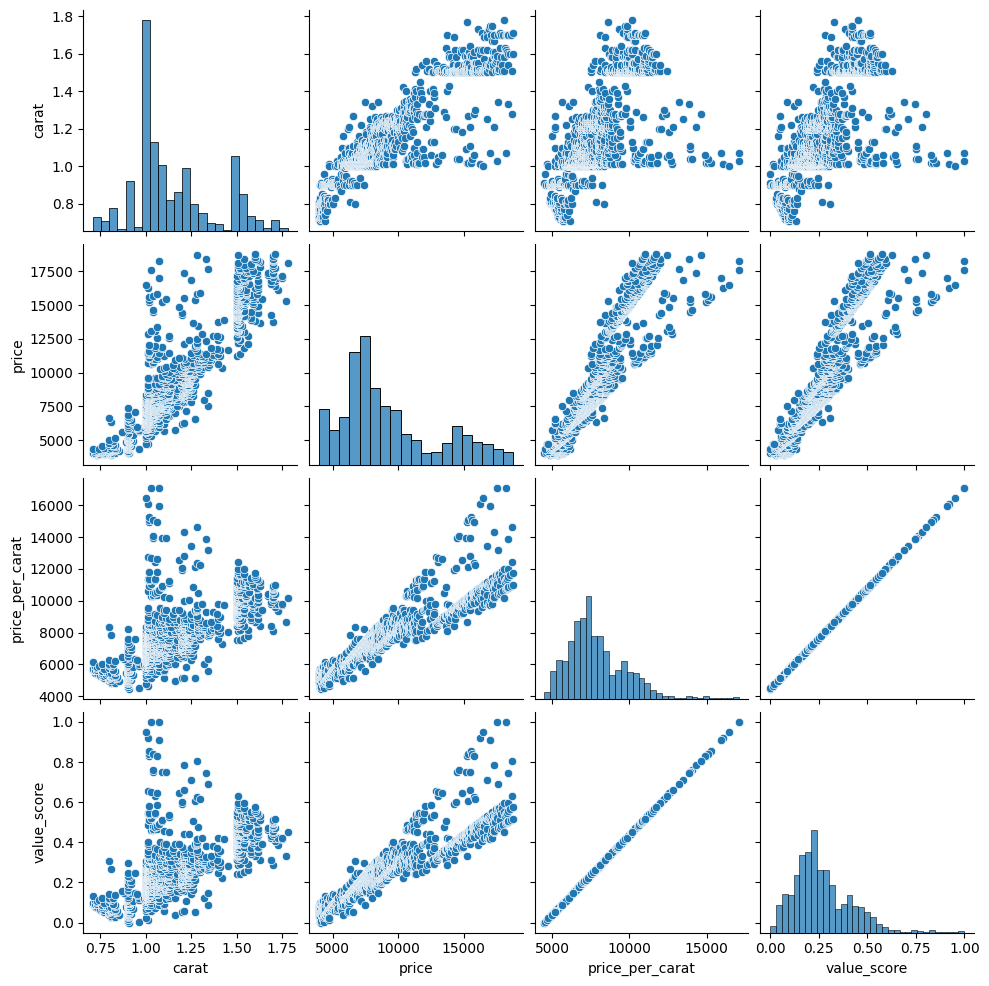

In [6]:
# 1. Scatter plot: carat vs price, colored by cut
sns.scatterplot(data=premium_df, x='carat', y='price', hue='cut')
plt.title("Carat vs Price (Cut)")
plt.show()

# 2. Scatter plot: volume vs price_per_carat, colored by clarity
sns.scatterplot(data=premium_df, x='volume', y='price_per_carat', hue='clarity')
plt.title("Volume vs Price per Carat (Clarity)")
plt.show()

# 3. Pair plot for selected columns
sns.pairplot(premium_df[['carat', 'price', 'price_per_carat', 'value_score']])
plt.show()